# 02 — stSNR metric behavior under degradations

**Purpose:** understand what the scoring metric actually punishes before building any model.

The stSNR score is a 50/50 average of sSNR (spatial) and tSNR (temporal). Those two components can move in opposite directions. A model that naively smooths can *improve* sSNR while *destroying* tSNR.

In [2]:
from pathlib import Path
import numpy as np
from load_data import load_validation_stacks
from cidc import load_stack

# Load full stacks
DATA = Path("/home/sarpk/python-tools/denoising_calcium/workspace/data")
f0_full = np.asarray(load_stack(DATA / "val" / "F0.tif"), dtype=np.float32)
f1_full = np.asarray(load_stack(DATA / "val" / "F1.tif"), dtype=np.float32)

# Extract crops: first 200 frames, top-left 128×128
clean = f0_full[:200, :128, :128]
noisy1 = f1_full[:200, :128, :128]

print(f"clean  shape={clean.shape}  mean={clean.mean():.1f}  max={clean.max():.0f}")
print(f"noisy1 shape={noisy1.shape}  mean={noisy1.mean():.1f}  max={noisy1.max():.0f}")

clean  shape=(200, 128, 128)  mean=257.8  max=2045
noisy1 shape=(200, 128, 128)  mean=257.8  max=2348


## Experiment A1 — Spatial blur (input = clean F0)

Apply 2D Gaussian blur to each frame independently (sigma 0 → 6 px).
This isolates the metric geometry without confounding noise.

**Result:** spatial blur hurts sSNR more than tSNR (neighboring pixels share temporal dynamics).

In [3]:
from metrics import spatial_blur_sweep

blur_results = spatial_blur_sweep(clean)

Spatial blur sweep:
  sigma=0.0  sSNR=210.77  tSNR=190.88  stSNR=200.82
  sigma=0.5  sSNR=32.75  tSNR=39.58  stSNR=36.17
  sigma=1.0  sSNR=22.84  tSNR=29.72  stSNR=26.28
  sigma=1.5  sSNR=19.47  tSNR=26.31  stSNR=22.89
  sigma=2.0  sSNR=17.56  tSNR=24.38  stSNR=20.97
  sigma=3.0  sSNR=15.49  tSNR=22.25  stSNR=18.87
  sigma=4.0  sSNR=14.37  tSNR=21.11  stSNR=17.74
  sigma=6.0  sSNR=13.15  tSNR=19.89  stSNR=16.52


## Experiment A2 — Additive Gaussian noise (input = clean F0)

Add zero-mean Gaussian noise with std σ (0 → 200 ADU).

**Result:** additive noise hurts sSNR and tSNR equally (symmetric degradation).

In [4]:
from metrics import additive_noise_sweep

noise_results = additive_noise_sweep(clean)


Additive noise sweep:
  sigma=  0  sSNR=210.77  tSNR=190.88  stSNR=200.82
  sigma= 10  sSNR=28.62  tSNR=27.89  stSNR=28.26
  sigma= 20  sSNR=22.60  tSNR=21.87  stSNR=22.24
  sigma= 40  sSNR=16.58  tSNR=15.85  stSNR=16.21
  sigma= 80  sSNR=10.56  tSNR=9.83  stSNR=10.20
  sigma=150  sSNR=5.10  tSNR=4.36  stSNR=4.73
  sigma=200  sSNR=2.60  tSNR=1.87  stSNR=2.23


## Metric Geometry: sSNR vs tSNR

Plot the (sSNR, tSNR) points for blur and noise perturbations.
- Blur curve is *above* the diagonal (tSNR > sSNR)
- Noise curve is *on* the diagonal (tSNR ≈ sSNR)

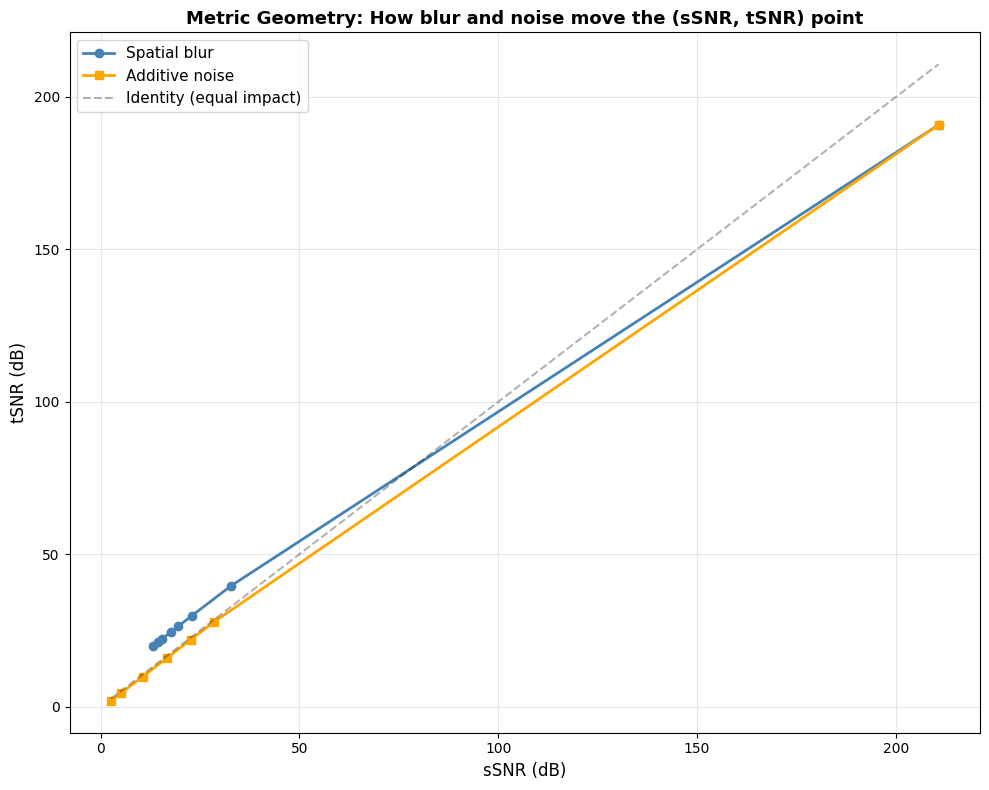

In [5]:
from plots import plot_metric_geometry

plot_metric_geometry(blur_results, noise_results)

## Experiment B — Temporal smoothing (input = noisy F1)

Apply temporal smoothing to noisy F1, score against clean F0.
This is the actual denoising scenario.

**Key finding:** sSNR improves at small windows, but tSNR collapses at large windows (transients blurred away).

In [6]:
from metrics import temporal_smooth_sweep

smooth_results = temporal_smooth_sweep(noisy1, clean)


Temporal smoothing sweep (noisy input → F0 reference):
  window=  1  sSNR=8.77  tSNR=8.14  stSNR=8.46
  window=  3  sSNR=13.52  tSNR=12.91  stSNR=13.22
  window=  5  sSNR=15.72  tSNR=15.12  stSNR=15.42
  window=  7  sSNR=17.15  tSNR=16.56  stSNR=16.85
  window= 11  sSNR=19.03  tSNR=18.43  stSNR=18.73
  window= 17  sSNR=20.75  tSNR=20.09  stSNR=20.42
  window= 31  sSNR=22.75  tSNR=21.88  stSNR=22.31
  window= 63  sSNR=23.74  tSNR=22.59  stSNR=23.16
  window=101  sSNR=22.87  tSNR=22.03  stSNR=22.45


In [7]:
from analysis import analyze_blur_results, analyze_noise_results, analyze_smooth_results

analyze_blur_results(blur_results)
analyze_noise_results(noise_results)
analyze_smooth_results(smooth_results)


Spatial blur analysis: gap = tSNR − sSNR
  sigma    sSNR    tSNR      gap  linear ratio
  ------------------------------------------------
    0.5   32.75   39.58    +6.83        4.82x
    1.0   22.84   29.72    +6.88        4.87x
    1.5   19.47   26.31    +6.85        4.84x
    2.0   17.56   24.38    +6.81        4.80x
    3.0   15.49   22.25    +6.77        4.75x
    4.0   14.37   21.11    +6.73        4.71x
    6.0   13.15   19.89    +6.74        4.72x

  Mean gap = 6.80 dB (constant across sigmas)
  Interpretation: spatial blur always hurts sSNR more than tSNR by ~4.8x

Additive noise analysis: gap = tSNR − sSNR
  sigma    sSNR    tSNR      gap
  ------------------------------
     10   28.62   27.89    -0.73
     20   22.60   21.87    -0.73
     40   16.58   15.85    -0.73
     80   10.56    9.83    -0.73
    150    5.10    4.36    -0.73
    200    2.60    1.87    -0.73

  Mean gap = -0.73 dB (near zero)
  Interpretation: additive noise hurts sSNR and tSNR equally

Temporal smoo

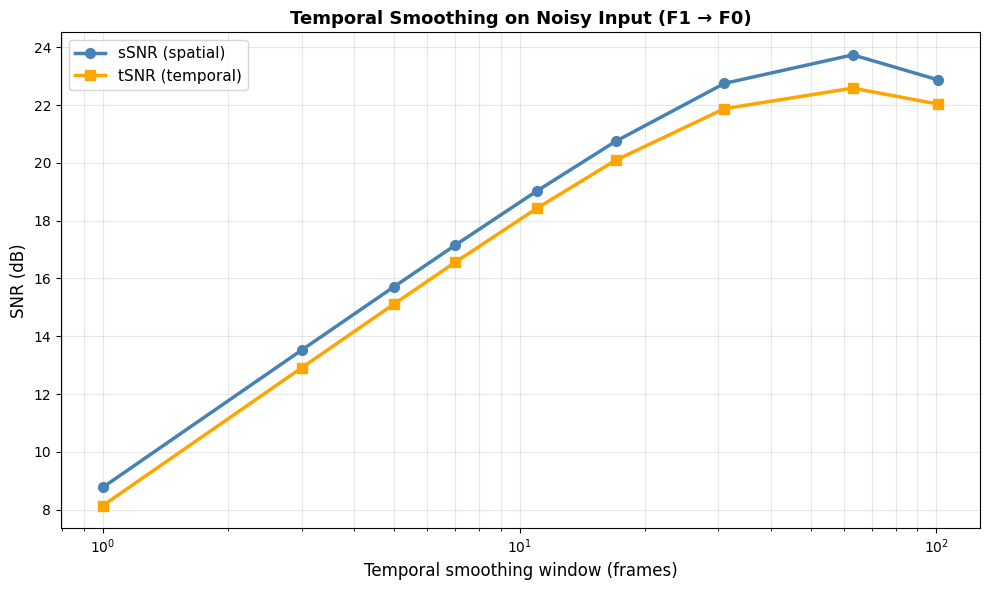

In [8]:
from plots import plot_temporal_smoothing

plot_temporal_smoothing(smooth_results)

## Summary

**Architecture decision:** Use voxel-level (pixel-time) training, not temporal smoothing.

- Naive temporal smoothing trades off tSNR for sSNR → net loss
- Spatial blur shows tSNR is robust to spatial mixing (neighboring pixels correlated)
- But temporal mixing destroys tSNR (transients are local in time)
- The 50/50 stSNR metric penalizes spatial-only denoisers (can't raise tSNR)
- N2V3D blind-spot masking respects both spatial and temporal structure → better tSNR gain